# Activity: Learning Hidden Markov Model Parameters with Baum-Welch
In the Watch-Demo, we built a three-state Hidden Markov Model (HMM) with hidden mood states and observable emoji outputs, and simulated it with known parameters. This activity reverses the question: given only observation sequences generated by that model, can we recover the transition matrix $\mathbf{P}$ and the emission matrix $\mathbf{E}$? We generate synthetic observations from the demo model, fit an HMM with the Baum-Welch algorithm from a random initialization, compare the learned parameters to the truth, and measure how data size and emission noise change the quality of the fit.

> __Learning Objectives:__
>
> After completing this activity, students will be able to:
> * __Generate synthetic observation data from a known HMM:__ use forward sampling to produce observation sequences from the demo's three-state mood model, keeping only the observations for fitting.
> * __Fit HMM parameters with Baum-Welch:__ run the expectation-maximization iteration from a random initialization and verify that the log-likelihood $\mathcal{L}_{k}$ does not decrease between iterations.
> * __Evaluate parameter recovery:__ align the learned states to the true states, measure the errors $\|\hat{\mathbf{P}}-\mathbf{P}\|_{F}$ and $\|\hat{\mathbf{E}}-\mathbf{E}\|_{F}$, and quantify how the number of training sequences and the emission noise change these errors.

Let's get started.
___

## Theory refresher: the learning problem
The Baum-Welch algorithm solves the learning problem: given observation sequences $\mathbf{o}^{(1)},\ldots,\mathbf{o}^{(N)}$ and the sizes of the state spaces, estimate the parameters $(\mathbf{P},\mathbf{E},\pi_{0})$ that best explain the data. It is an instance of the expectation-maximization (EM) algorithm:
* __E-step:__ with the current parameters, compute the state posterior $\gamma_{t}(i)$ and the transition posterior $\xi_{t}(i,j)$ for every sequence from the forward variables $\alpha_{t}(i)$ and backward variables $\beta_{t}(i)$.
* __M-step:__ re-estimate $\pi_{0}$, $\mathbf{P}$, and $\mathbf{E}$ from the expected state occupancies and transition counts.

Each iteration does not decrease the log-likelihood $\mathcal{L}_{k}$, and the iteration stops when $|\mathcal{L}_{k}-\mathcal{L}_{k-1}|<\epsilon$ or $k\geq{K}_{\text{max}}$. Baum-Welch converges to a local maximum of the likelihood; the result depends on the initialization. For the full development of $\alpha$, $\beta$, $\gamma$, and $\xi$, see the lecture notebook `CHEME-145-M3-Lecture-HiddenMarkovModel-Read-Page.ipynb`.
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file. The `Include.jl` file sets paths, loads required external packages, and includes the module's local source files (`src/Types.jl`, `src/Factory.jl`, `src/Compute.jl`) holding the types and algorithms used in this activity.

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating 

project at `~/Desktop/julia_work/CHEME-140-eCornell-Repository/courses/CHEME-145/module-3`


## Task 1: Build the true model
We use the same three-state mood model as the Watch-Demo. The hidden states are $\mathcal{S}\equiv\left\{\text{happy},\text{neutral},\text{sad}\right\}$, and the observable outputs are the emojis $\mathcal{O}\equiv\left\{😄,😐,😞\right\}$. The transition matrix $\mathbf{P}\in\mathbb{R}^{3\times{3}}$ and the emission matrix $\mathbf{E}\in\mathbb{R}^{3\times{3}}$ take the demo values, and we use a uniform initial distribution $\pi_{0}=(1/3,1/3,1/3)$. The `build(...)` factory method checks that the rows of $\mathbf{P}$ and $\mathbf{E}$ and the vector $\pi_{0}$ are valid probability distributions.

In [2]:
number_of_hidden_states = 3; # how many hidden states do we have?
number_of_observable_states = 3; # how many observable states do we have?

P_true = [
    0.05 0.95 0.0 ; # moves for state 1 = happy
    0.6 0.2 0.2 ; # moves for state 2 = neutral
    0.0 0.3 0.7 ; # moves for state 3 = sad
];

E_true = [
    0.90 0.05 0.05 ; # 1 happy (but sometimes we see other faces)
    0.05 0.90 0.05 ; # 2 neutral (but sometimes we see other faces)
    0.05 0.05 0.90 ; # 3 sad (but sometimes we see other faces)
];

π₀_true = [1/3, 1/3, 1/3]; # uniform initial state distribution

hmm_true = build(MyHiddenMarkovModel, (P = P_true, E = E_true, π₀ = π₀_true));

## Task 2: Generate synthetic observations
We generate `number_of_sequences = 50` observation sequences, each of length `sequence_length = 200`, by forward sampling from the true model with the `simulate(...)` method. The sampler returns both the hidden states and the observations for each sequence, but we keep __only the observations__: the fitter never sees the hidden states. We seed the random number generator so the notebook reproduces exactly.

In [3]:
number_of_sequences = 50; # how many observation sequences do we generate?
sequence_length = 200; # length T of each sequence
rng_data = Xoshiro(2026); # seeded random number generator (reproducibility)

training_data = simulate(hmm_true, sequence_length; N = number_of_sequences, rng = rng_data);
observation_sequences = [sequence.observed for sequence ∈ training_data]; # keep only the observations

Let's look at the first 20 observations of the first sequence as emojis:

In [4]:
observable_emoji_map = Dict{Int,String}(1 => "😄", 2 => "😐", 3 => "😞");
[observable_emoji_map[o] for o ∈ observation_sequences[1][1:20]] |> v -> join(v, " ") |> println;

😐 😄 😐 😐 😄 😐 😄 😞 😐 😄 😐 😞 😞 😐 😞 😞 😞 😞 😞 😞


## Task 3: Fit the model with Baum-Welch
We build a `MyBaumWelchModel` solver with `maxiterations = 500` and tolerance $\epsilon=10^{-6}$, and call `solve(...)` on the observation sequences. The solver initializes $(\mathbf{P},\mathbf{E},\pi_{0})$ as random row-stochastic matrices drawn from a seeded random number generator, then alternates the E-step and M-step until $|\mathcal{L}_{k}-\mathcal{L}_{k-1}|<\epsilon$ or the iteration limit is reached.

In [5]:
rng_fit = Xoshiro(11); # seeds the random initialization
solver = build(MyBaumWelchModel, (maxiterations = 500, ϵ = 1e-6));
result = solve(solver, observation_sequences;
    number_of_hidden_states = number_of_hidden_states,
    number_of_observable_states = number_of_observable_states, rng = rng_fit);
println("Converged after $(result.iterations) iterations. Final log-likelihood ℒ = $(round(result.loglikelihood_history[end], digits = 2))");

Converged after 204 iterations. Final log-likelihood ℒ = -8781.45


### Check: Does the log-likelihood increase at every iteration?
The EM guarantee from the lecture states that each Baum-Welch iteration does not decrease the log-likelihood $\mathcal{L}_{k}$. Let's verify this on the fitted history using the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert), then plot $\mathcal{L}_{k}$ versus the iteration count $k$:

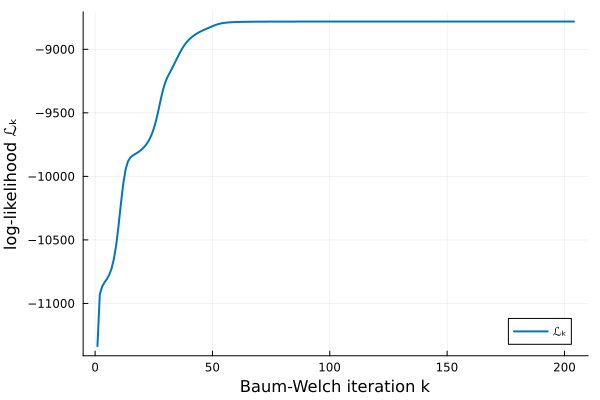

In [6]:
let
    ℒ = result.loglikelihood_history;
    @assert all(diff(ℒ) .≥ -1e-6) # non-decreasing (up to numerical roundoff)
    plot(1:length(ℒ), ℒ, lw = 2, c = colors[1], label = "ℒₖ",
        xlabel = "Baum-Welch iteration k", ylabel = "log-likelihood ℒₖ")
end

## Task 4: Compare the learned model to the truth
Baum-Welch never sees the state labels, so the learned states come back in arbitrary order: the fitter may call "happy" state 3. Before comparing to the truth, we align the learned states to the true states with the `align_states(...)` method, which searches all permutations of the state labels for the one minimizing $\|\hat{\mathbf{P}}-\mathbf{P}\|_{F}+\|\hat{\mathbf{E}}-\mathbf{E}\|_{F}$, where $\|\cdot\|_{F}$ denotes the Frobenius norm.

In [7]:
(σ, P̂, Ê) = align_states(result.P, result.E, P_true, E_true);
println("state alignment σ = $(σ)");
println("‖P̂ - P‖F = $(round(norm(P̂ - P_true), digits = 4))");
println("‖Ê - E‖F = $(round(norm(Ê - E_true), digits = 4))");

state alignment σ = [1, 2, 3]


‖P̂ - P‖F = 0.0429
‖Ê - E‖F = 0.0223


Let's put the aligned learned parameters next to the true values. Each row of the tables below is a hidden state; learned values wear a hat:

In [8]:
let
    S = number_of_hidden_states;
    state_names = ["happy", "neutral", "sad"];

    data_P = Matrix{Any}(undef, S, 1 + 2*S);
    data_E = Matrix{Any}(undef, S, 1 + 2*S);
    for i ∈ 1:S
        data_P[i, 1] = state_names[i];
        data_E[i, 1] = state_names[i];
        for j ∈ 1:S
            data_P[i, 1 + j] = round(P̂[i, j], digits = 3);
            data_P[i, 1 + S + j] = round(P_true[i, j], digits = 3);
            data_E[i, 1 + j] = round(Ê[i, j], digits = 3);
            data_E[i, 1 + S + j] = round(E_true[i, j], digits = 3);
        end
    end
    pretty_table(data_P; column_labels = ["state", "p̂ᵢ₁", "p̂ᵢ₂", "p̂ᵢ₃", "pᵢ₁", "pᵢ₂", "pᵢ₃"]);
    pretty_table(data_E; column_labels = ["state", "êᵢ₁", "êᵢ₂", "êᵢ₃", "eᵢ₁", "eᵢ₂", "eᵢ₃"]);
end

┌─────────┬───────┬───────┬───────┬──────┬──────┬─────┐
│   state │   p̂ᵢ₁ │   p̂ᵢ₂ │   p̂ᵢ₃ │  pᵢ₁ │  pᵢ₂ │ pᵢ₃ │
├─────────┼───────┼───────┼───────┼──────┼──────┼─────┤
│   happy │ 0.055 │ 0.938 │ 0.007 │ 0.05 │ 0.95 │ 0.0 │
│ neutral │ 0.584 │ 0.184 │ 0.232 │  0.6 │  0.2 │ 0.2 │
│     sad │ 0.008 │ 0.293 │ 0.699 │  0.0 │  0.3 │ 0.7 │
└─────────┴───────┴───────┴───────┴──────┴──────┴─────┘
┌─────────┬───────┬───────┬───────┬──────┬──────┬──────┐
│   state │   êᵢ₁ │   êᵢ₂ │   êᵢ₃ │  eᵢ₁ │  eᵢ₂ │  eᵢ₃ │
├─────────┼───────┼───────┼───────┼──────┼──────┼──────┤
│   happy │ 0.907 │ 0.052 │ 0.041 │  0.9 │ 0.05 │ 0.05 │
│ neutral │ 0.046 │ 0.901 │ 0.053 │ 0.05 │  0.9 │ 0.05 │
│     sad │ 0.045 │ 0.065 │  0.89 │ 0.05 │ 0.05 │  0.9 │
└─────────┴───────┴───────┴───────┴──────┴──────┴──────┘


## Experiment 1: Data size
How much data does Baum-Welch need? Holding the model and the sequence length $T=200$ fixed, we regenerate a fresh training set with $N\in\{2,10,50,200\}$ sequences, refit, realign, and print the parameter errors. More data gives better estimates of the expected transition and emission counts, so both errors shrink as $N$ grows.

> __Try it yourself:__ change the values in the tuple `(2, 10, 50, 200)` in the cell below (or change `sequence_length` above and re-run the notebook) and watch how the errors respond.

In [9]:
let
    for N_try ∈ (2, 10, 50, 200)
        sequences_try = [s.observed for s ∈ simulate(hmm_true, sequence_length; N = N_try, rng = Xoshiro(2026))];
        result_try = solve(solver, sequences_try;
            number_of_hidden_states = number_of_hidden_states,
            number_of_observable_states = number_of_observable_states, rng = Xoshiro(11));
        (_, P̂_try, Ê_try) = align_states(result_try.P, result_try.E, P_true, E_true);
        println("N = $(lpad(N_try, 3)):  ‖P̂ - P‖F = $(round(norm(P̂_try - P_true), digits = 4)),  ‖Ê - E‖F = $(round(norm(Ê_try - E_true), digits = 4))");
    end
end

N =   2:  ‖P̂ - P‖F = 0.0924,  ‖Ê - E‖F = 0.1229
N =  10:  ‖P̂ - P‖F = 0.0523,  ‖Ê - E‖F = 0.0556


N =  50:  ‖P̂ - P‖F = 0.0429,  ‖Ê - E‖F = 0.0223


N = 200:  ‖P̂ - P‖F = 0.0187,  ‖Ê - E‖F = 0.0138


## Experiment 2: Emission noise
What happens when the observations carry less information about the hidden state? We rebuild the true model with emission diagonal $d\in\{0.9,0.7,0.5\}$ and off-diagonal entries $(1-d)/2$, regenerate $N=50$ training sequences from each model, refit, and print the parameter errors. As $d$ falls toward $1/3$, the emission rows approach the uniform distribution, the observations say less about the hidden mood, and recovery degrades sharply once the diagonal drops below $0.9$. This is what "hidden" means: the harder the states are to see through the observations, the harder they are to learn.

> __Try it yourself:__ set $d = 0.4$ and compare the errors. What do you expect at exactly $d = 1/3$?

In [10]:
let
    for d ∈ (0.9, 0.7, 0.5)
        off = (1 - d)/2;
        E_noisy = [
            d off off ;
            off d off ;
            off off d ;
        ];
        hmm_noisy = build(MyHiddenMarkovModel, (P = P_true, E = E_noisy, π₀ = π₀_true));
        sequences_noisy = [s.observed for s ∈ simulate(hmm_noisy, sequence_length; N = 50, rng = Xoshiro(2026))];
        result_noisy = solve(solver, sequences_noisy;
            number_of_hidden_states = number_of_hidden_states,
            number_of_observable_states = number_of_observable_states, rng = Xoshiro(11));
        (_, P̂_noisy, Ê_noisy) = align_states(result_noisy.P, result_noisy.E, P_true, E_noisy);
        println("d = $(d):  ‖P̂ - P‖F = $(round(norm(P̂_noisy - P_true), digits = 4)),  ‖Ê - E‖F = $(round(norm(Ê_noisy - E_noisy), digits = 4))");
    end
end

d = 0.9:  ‖P̂ - P‖F = 0.0429,  ‖Ê - E‖F = 0.0223


d = 0.7:  ‖P̂ - P‖F = 0.7087,  ‖Ê - E‖F = 0.3623


d = 0.5:  ‖P̂ - P‖F = 0.7473,  ‖Ê - E‖F = 0.343


___
## Summary
In this activity, we generated synthetic observation sequences from the three-state mood model of the Watch-Demo and used the Baum-Welch algorithm to recover the transition matrix $\mathbf{P}$ and the emission matrix $\mathbf{E}$ from the observations alone.

> __Key Takeaways:__
>
> * __Baum-Welch learns HMM parameters from observations alone:__ starting from a random initialization, the EM iteration recovered $\mathbf{P}$ and $\mathbf{E}$ from emoji sequences without access to the hidden mood states, up to a permutation of the state labels.
> * __The log-likelihood does not decrease between iterations:__ the fitted history $\mathcal{L}_{k}$ is non-decreasing, consistent with the EM convergence guarantee from the lecture, and the iteration stops at a local maximum of the likelihood.
> * __Recovery quality depends on data size and emission noise:__ the errors $\|\hat{\mathbf{P}}-\mathbf{P}\|_{F}$ and $\|\hat{\mathbf{E}}-\mathbf{E}\|_{F}$ fall as the number of training sequences grows (Experiment 1) and grow sharply as the emission matrix approaches the uniform distribution, with recovery collapsing below a diagonal of $0.9$ (Experiment 2).

Together with the evaluation and decoding problems, the learning problem completes the three classic HMM problems from the lecture.

### Additional Resources
* Rabiner, L. R. (1989). A tutorial on hidden Markov models and selected applications in speech recognition. *Proceedings of the IEEE*, 77(2), 257–286.
* Lecture notebook: `CHEME-145-M3-Lecture-HiddenMarkovModel-Read-Page.ipynb` — full development of the forward, Viterbi, and Baum-Welch algorithms.